In [ ]:
%load_ext autoreload
%autoreload 2

import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import shap
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from config_file import config
from preprocessing import FeatureEngineer, preprocessor

warnings.filterwarnings('ignore')

plt.style.use("fivethirtyeight")
%matplotlib inline

In [2]:
train_data = pd.read_csv(config.paths.path_to_train)
train_data.set_index('PassengerId', inplace=True)

test_data = pd.read_csv(config.paths.path_to_test)
test_data.set_index('PassengerId', inplace=True)

In [3]:
train, test = train_data.copy(deep=True), test_data.copy(deep=True)
df = train

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


### EDA (Exploratory Data Analysis)

In [5]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


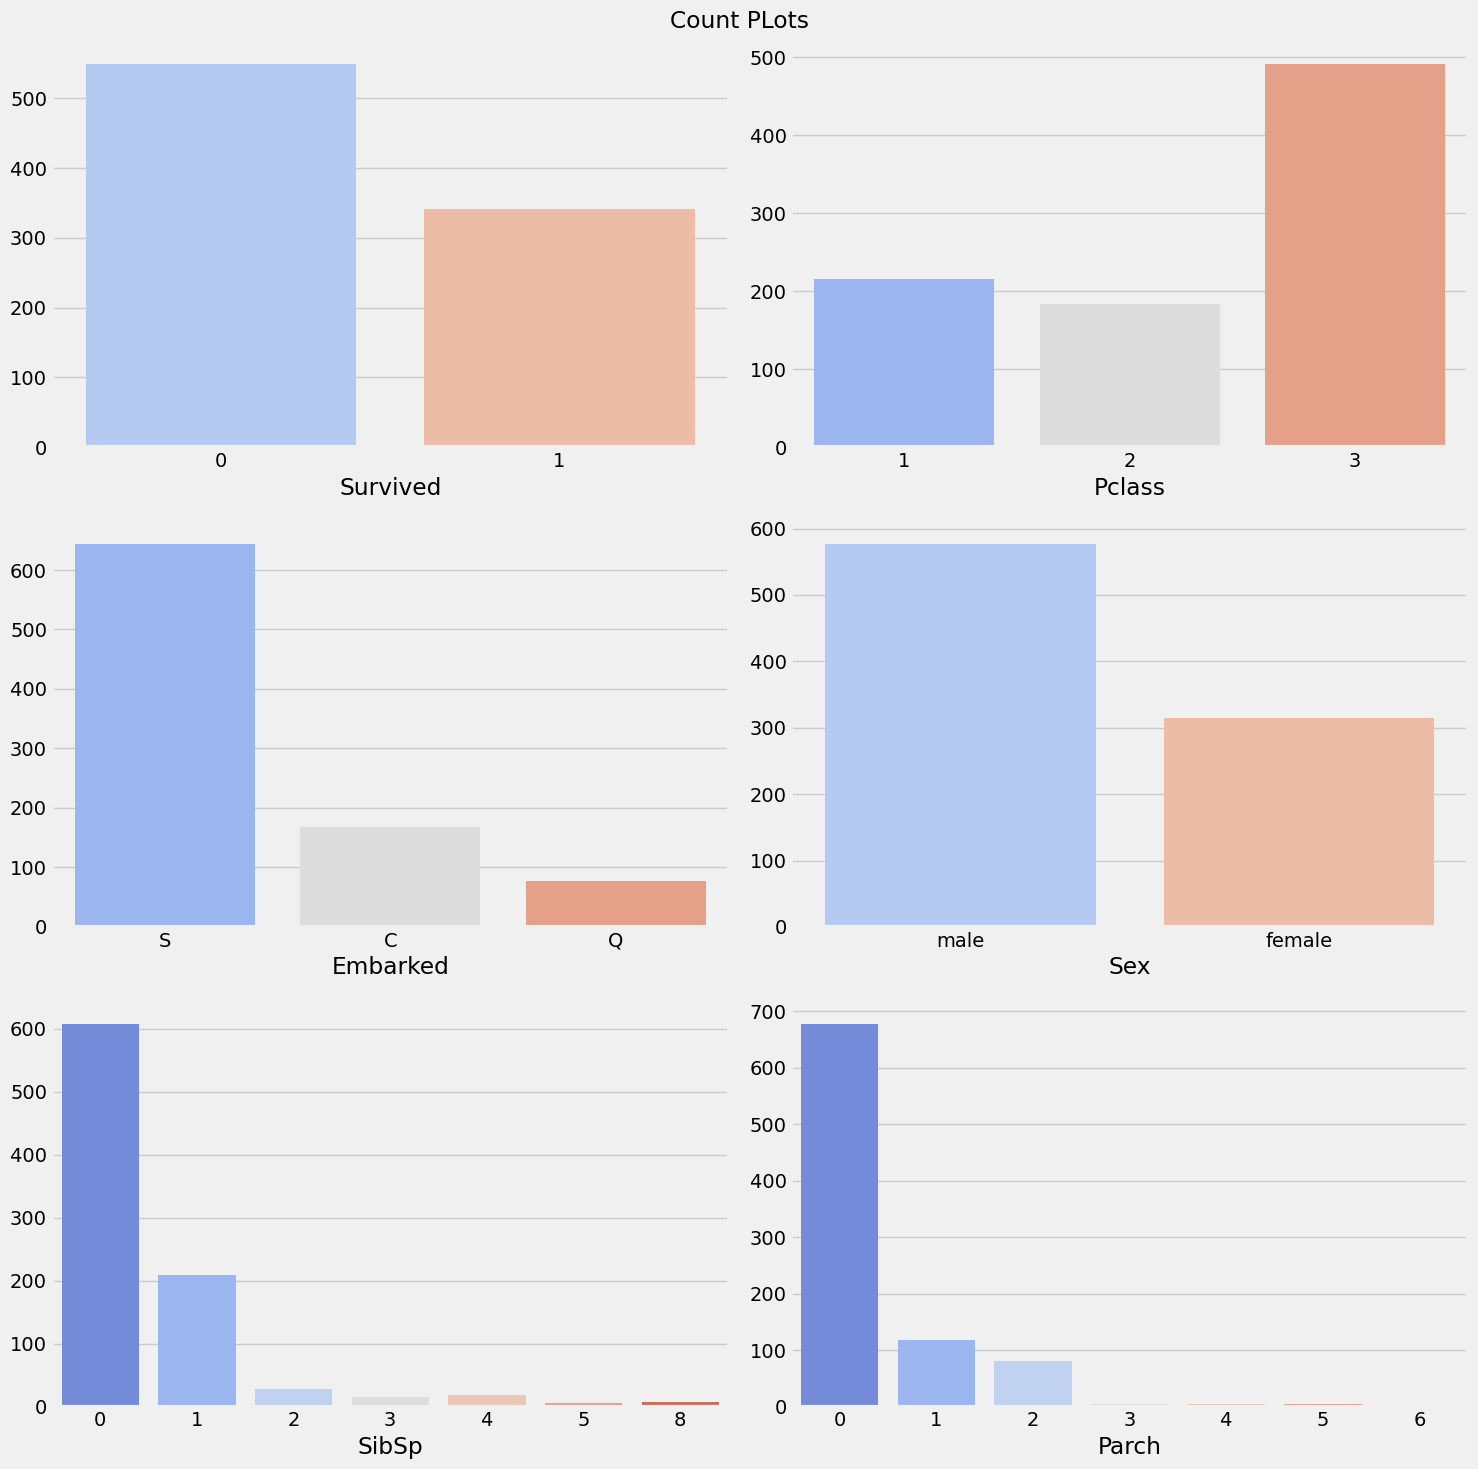

In [7]:
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(15,15))

fig.suptitle('Count PLots')

sns.countplot(df, x=config.target_column_name, palette='coolwarm', ax=ax[0, 0])
sns.countplot(df, x='Pclass', palette='coolwarm', ax=ax[0, 1])
sns.countplot(df, x='Embarked', palette='coolwarm', ax=ax[1, 0])
sns.countplot(df, x='Sex', palette='coolwarm', ax=ax[1, 1])
sns.countplot(df, x='SibSp', palette='coolwarm', ax=ax[2, 0])
sns.countplot(df, x='Parch', palette='coolwarm', ax=ax[2, 1])

[ax[i, j].set_ylabel('') for i in range(3) for j in range(2)]

plt.tight_layout()
plt.show()

- ```Survived``` : Дисбаланс классов незначительный
- ```Pclass``` : Подавляющее большинство пассажиров Титаника имели билет класса 3
- ```Embarked``` : Подавляющее большинство пассажиров Титаника выезжали из S (Sauthempton)
- ```Sex``` : Мужчин на корабле было почти в 2 раз больше
- ```SibSp & Parch``` : Основная масса людей имели на корабле не более 2 членов семьи

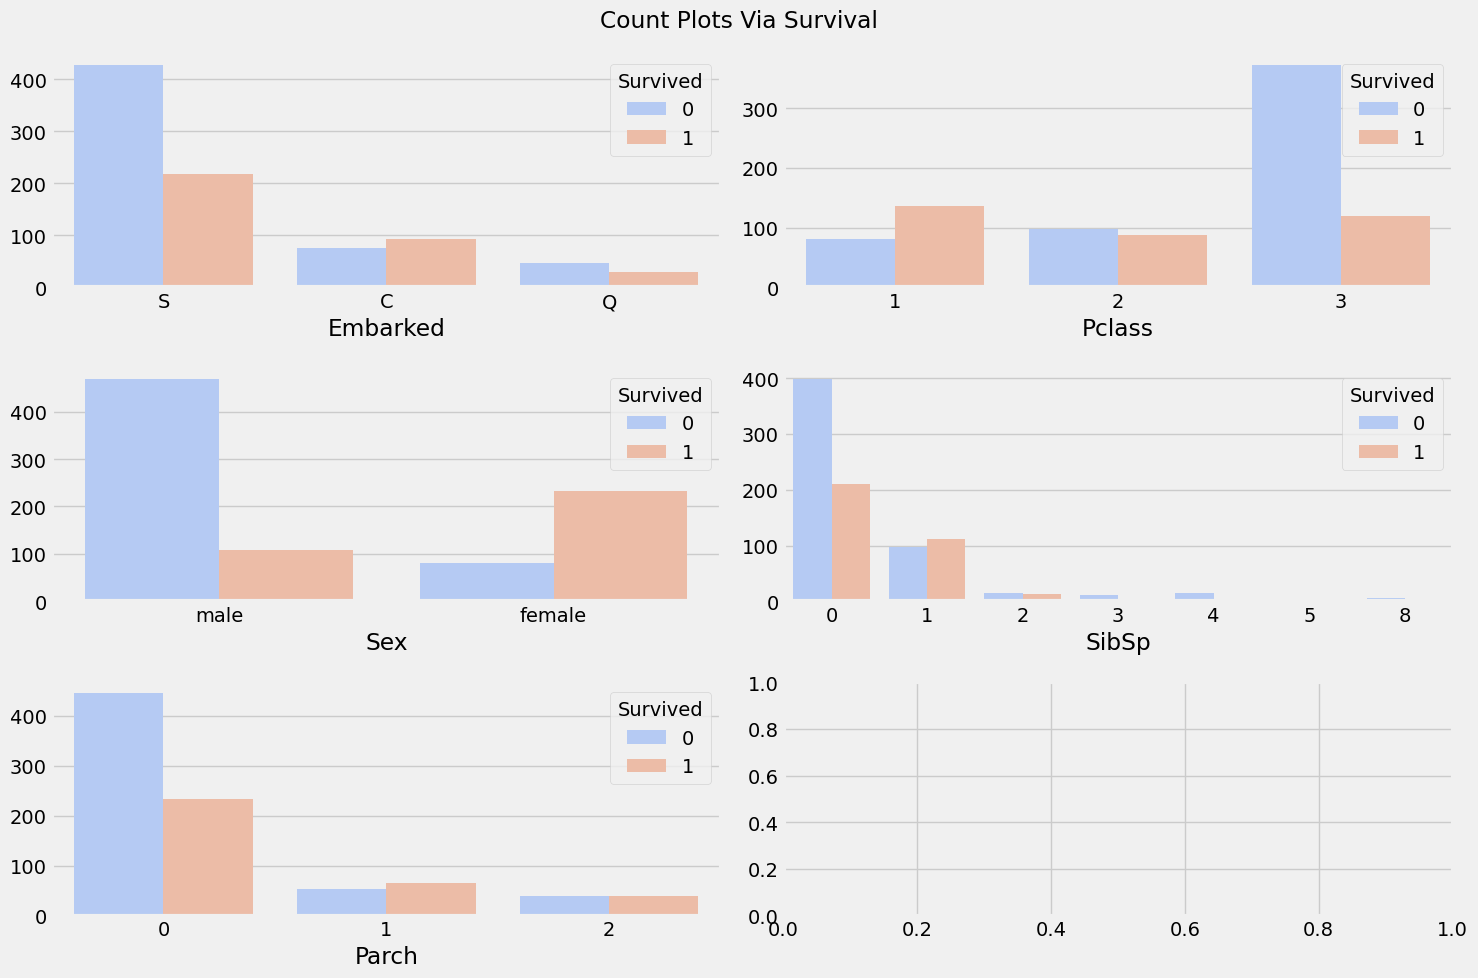

In [8]:
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(15,10))

fig.suptitle('Count Plots Via Survival')

sns.countplot(df, x='Embarked', palette='coolwarm', hue=config.target_column_name, ax=ax[0, 0])
sns.countplot(df, x='Pclass', palette='coolwarm', hue=config.target_column_name, ax=ax[0, 1])
sns.countplot(df, x='Sex', palette='coolwarm', hue=config.target_column_name, ax=ax[1, 0])
sns.countplot(df, x='SibSp', palette='coolwarm', hue=config.target_column_name, ax=ax[1, 1])
sns.countplot(df, x='Parch', palette='coolwarm', hue=config.target_column_name, order=[0, 1, 2], ax=ax[2, 0])

[ax[i, j].set_ylabel('') for i in range(3) for j in range(2)]

plt.tight_layout()
plt.show()

- ```Pclass``` : Пассажиры с классом 1 имели высокий шанс выживания по сравнению с другими
- ```Embarked``` : Выживших пассажиров из порта 'C' больше чем умерших
- ```Sex``` : Женщины имели гораздо больше шансов на выживание. Несмотря на то что мужчин на корабле было больше, выжило больше женщин 
- ```SibSp & Parch``` : Пассажиры на корабле с не более чем 2 членами семьи выживали заметно чаще других

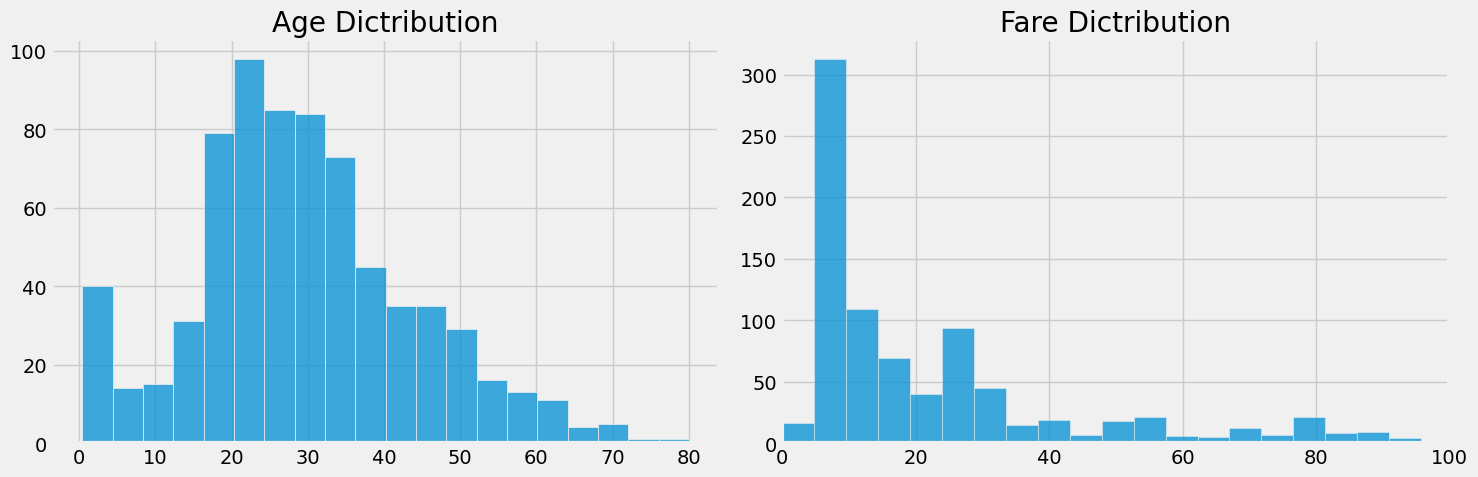

In [9]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,5))

sns.histplot(df['Age'], ax=ax[0])
ax[0].set_title('Age Dictribution')


sns.histplot(df['Fare'], ax=ax[1])
ax[1].set_xlim(0, 100)
ax[1].set_title('Fare Dictribution')

[(ax[i].set_ylabel(''), ax[i].set_xlabel('')) for i in range(2)]

plt.tight_layout()
plt.show()

- Распределение Fare скошено вправо. Мы можем отлогарифмировать эту колонку или применить бининг

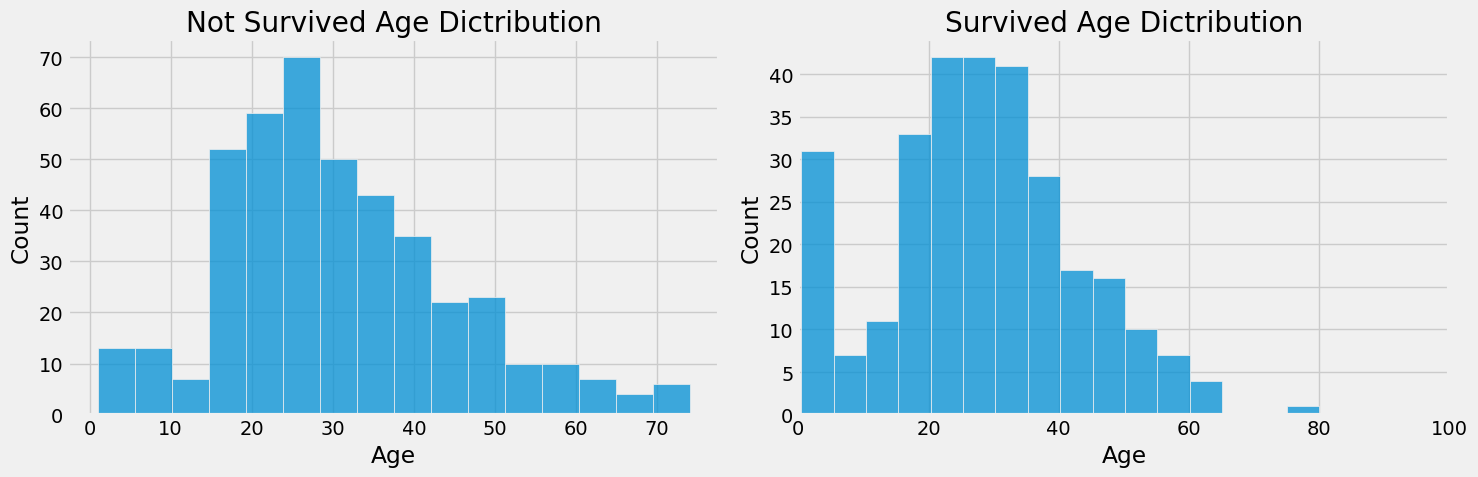

In [10]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,5))

sns.histplot(df[df[config.target_column_name] == 0]['Age'], ax=ax[0])
ax[0].set_title('Not Survived Age Dictribution')


sns.histplot(df[df[config.target_column_name] == 1]['Age'], ax=ax[1])
ax[1].set_xlim(0, 100)
ax[1].set_title('Survived Age Dictribution')

plt.tight_layout()
plt.show()

- Дети 0-5 лет имели очень высокую выживаемость
- Старики в силу возраста имеют низкую выживаемость 

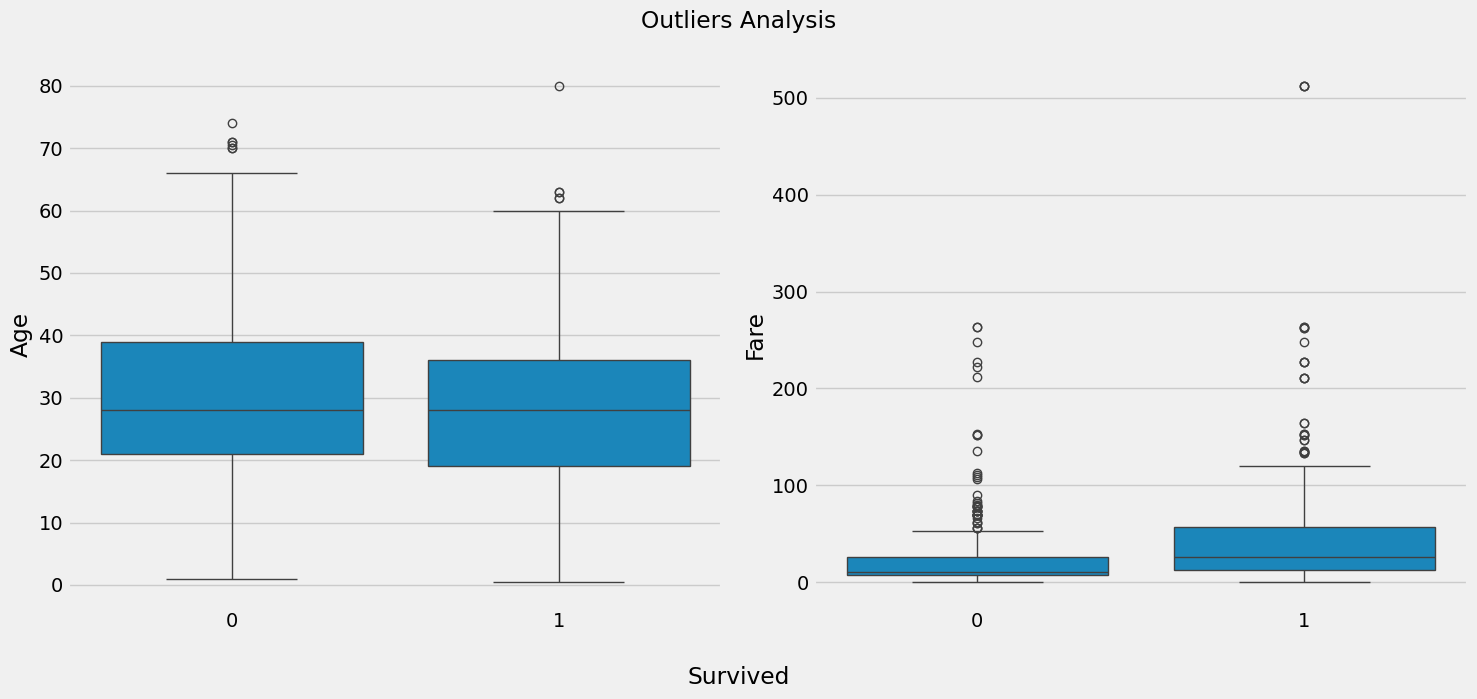

In [11]:
cols= ['Age', 'Fare'] 

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,7))

fig.suptitle('Outliers Analysis')
fig.supxlabel('Survived')

for idx, col in enumerate(cols):
    sns.boxplot(df, y=col, x='Survived', ax=ax[idx])
    
[ax[i].set_xlabel('') for i in range(len(cols))]

plt.tight_layout()
plt.show()

In [12]:
def outliers_search(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[col] > upper_bound) | (data[col] < lower_bound)]

    return outliers

print(outliers_search(df, 'Age').shape[0])
print(outliers_search(df, 'Fare').shape[0])


11
116


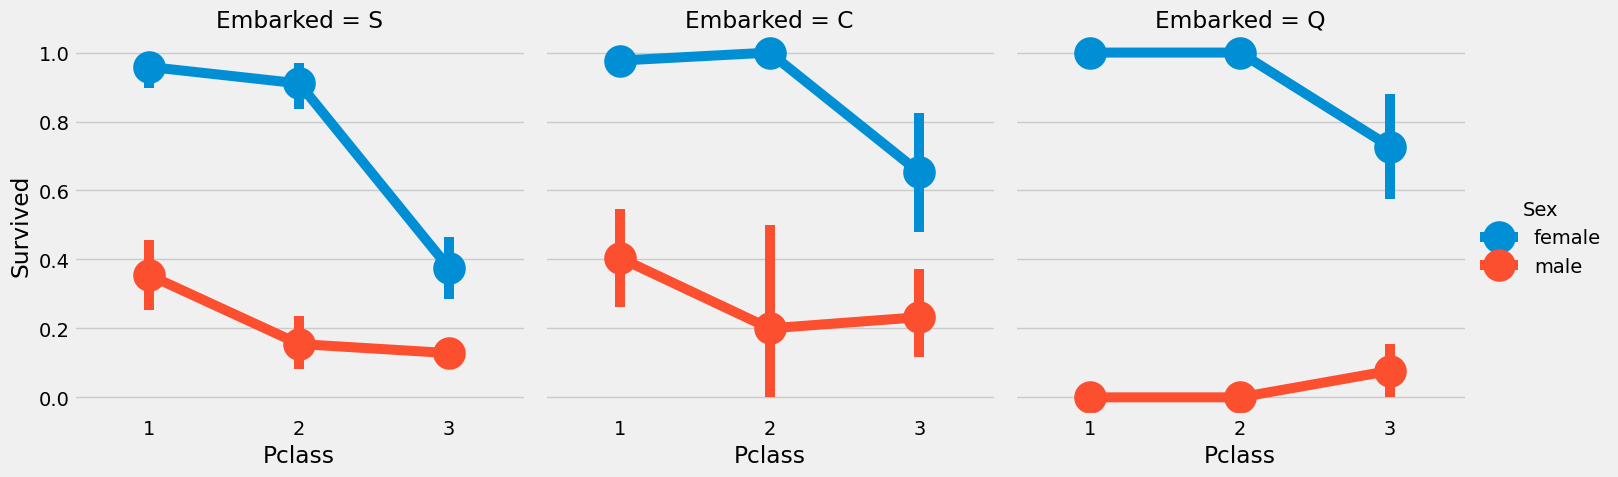

In [13]:
sns.catplot(data=df, x='Pclass',y=config.target_column_name,hue='Sex',col='Embarked', kind='point')
plt.show()

- Женщины севшие на Титаник в 'C' и 'Q' с билетами класса 1 и 2 имели почти 100% выживаемость. Севшие в 'S' с билетом 1 класса то же имели почти 100% выживаемость

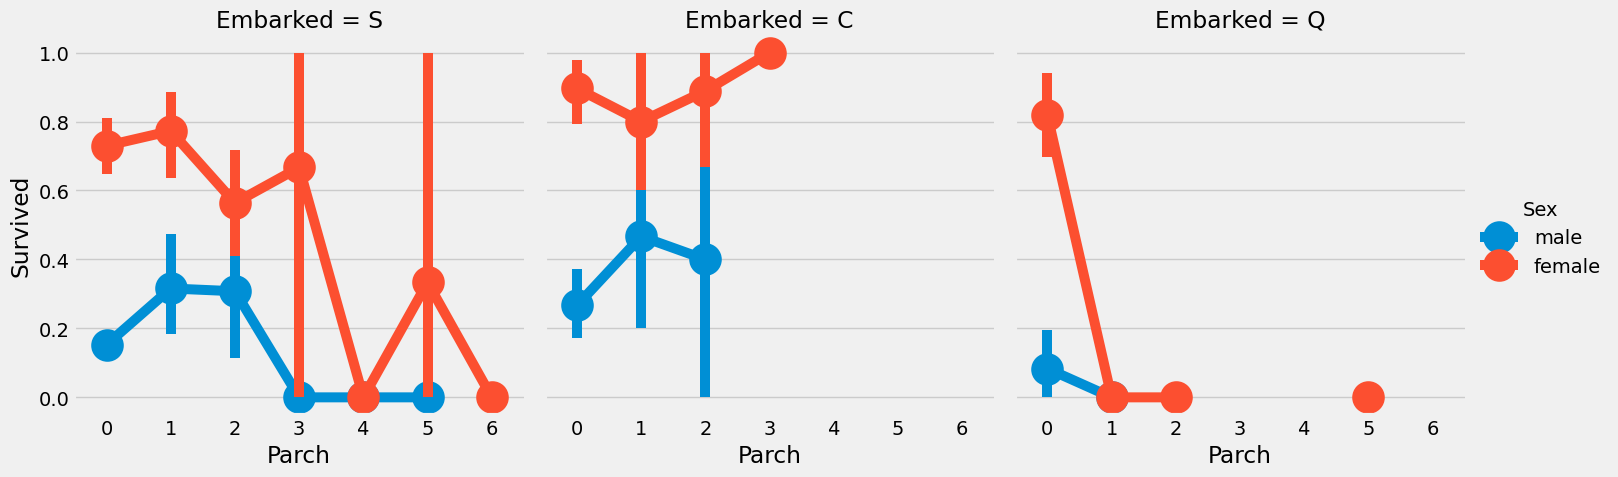

In [14]:
sns.catplot(data=df, x='Parch',y=config.target_column_name,hue='Sex',col='Embarked', kind='point')
plt.show()

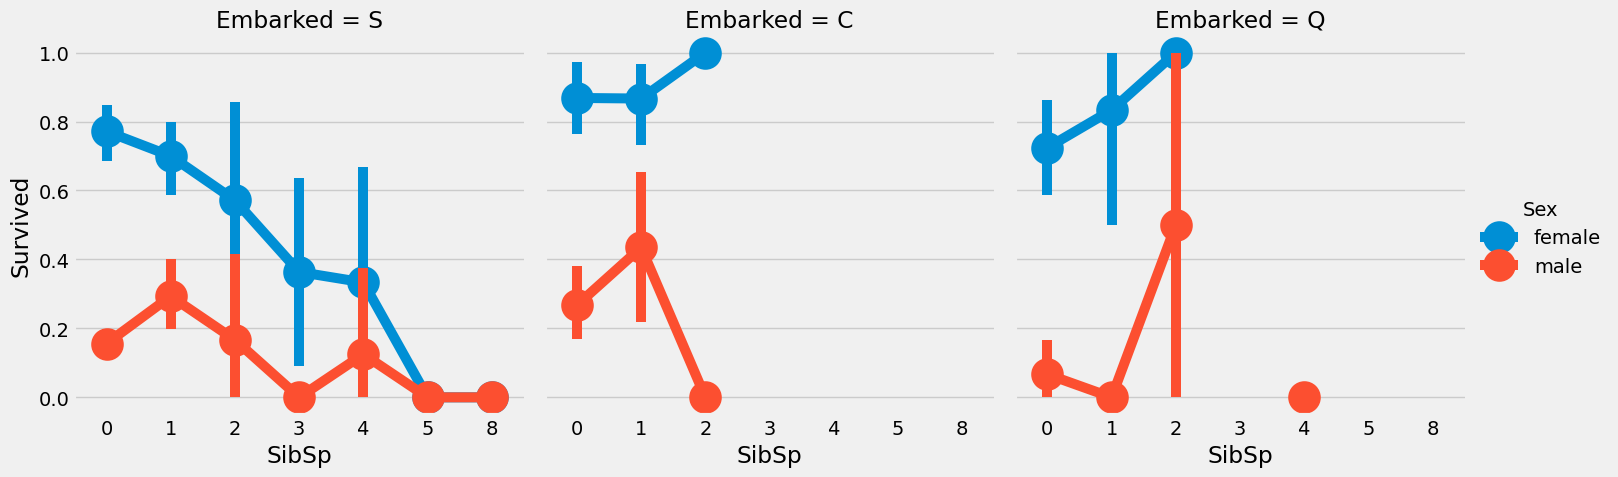

In [15]:
sns.catplot(data=df, x='SibSp',y=config.target_column_name,hue='Sex',col='Embarked', kind='point')
plt.show()

In [16]:
df.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [17]:
df[df['Embarked'].isnull()]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [18]:
# Номера билетов близкие к тем, что у людей с 
# пропусками выезжали из Sauthempton, поэтому 
# есть смысл заполнить их S (Sauthempton)
# Также подавляющее большинство пассажиров садились на борт именно в S (Sauthempton)

df[(df['Pclass'] == 1) & 
   (df['Sex'] == 'female') & 
   (df[config.target_column_name] == 1) & 
   (df['SibSp'] == 0) & 
   (df['Parch'] == 0)]\
   [['Embarked']].value_counts()

Embarked
C           17
S           14
Name: count, dtype: int64

In [19]:
pd.crosstab(df.Parch, df.Pclass, margins=True).style.background_gradient(cmap='summer_r')

Pclass,1,2,3,All
Parch,,,,
0,163,134,381,678
1,31,32,55,118
2,21,16,43,80
3,0,2,3,5
4,1,0,3,4
5,0,0,5,5
6,0,0,1,1
All,216,184,491,891


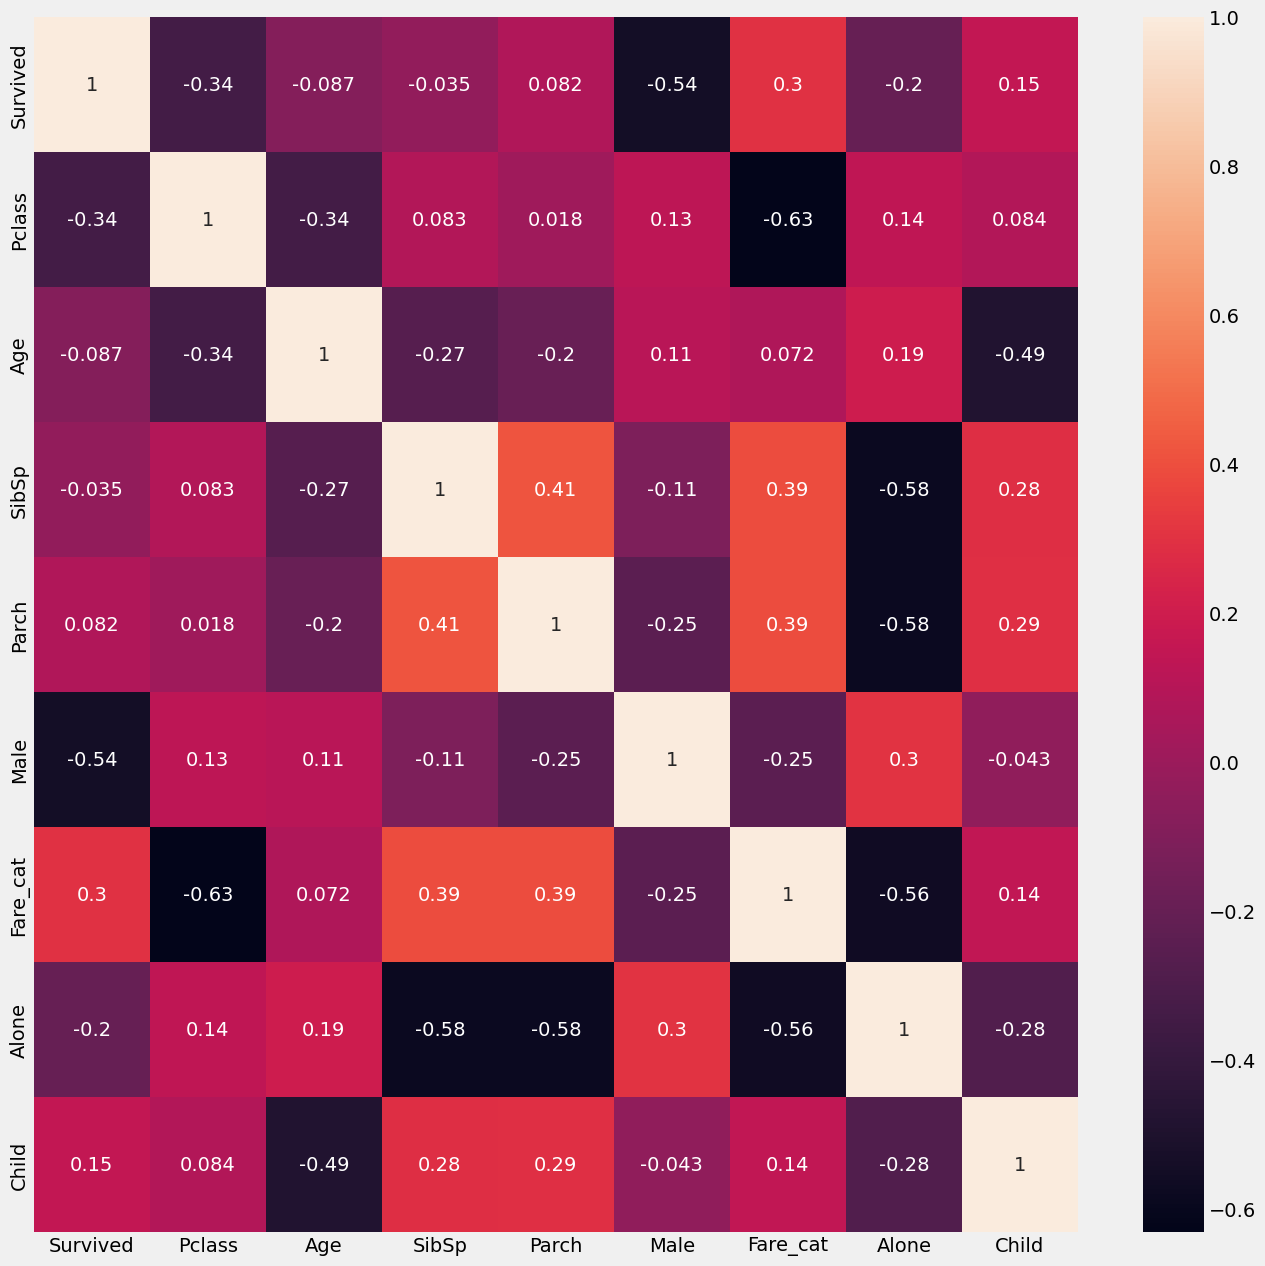

In [20]:
df1 = FeatureEngineer().fit_transform(df)

fig = plt.figure(figsize=(15,15))
sns.heatmap(df1.drop(columns=['Initial', 'Embarked']).corr(), annot=True)
plt.show()

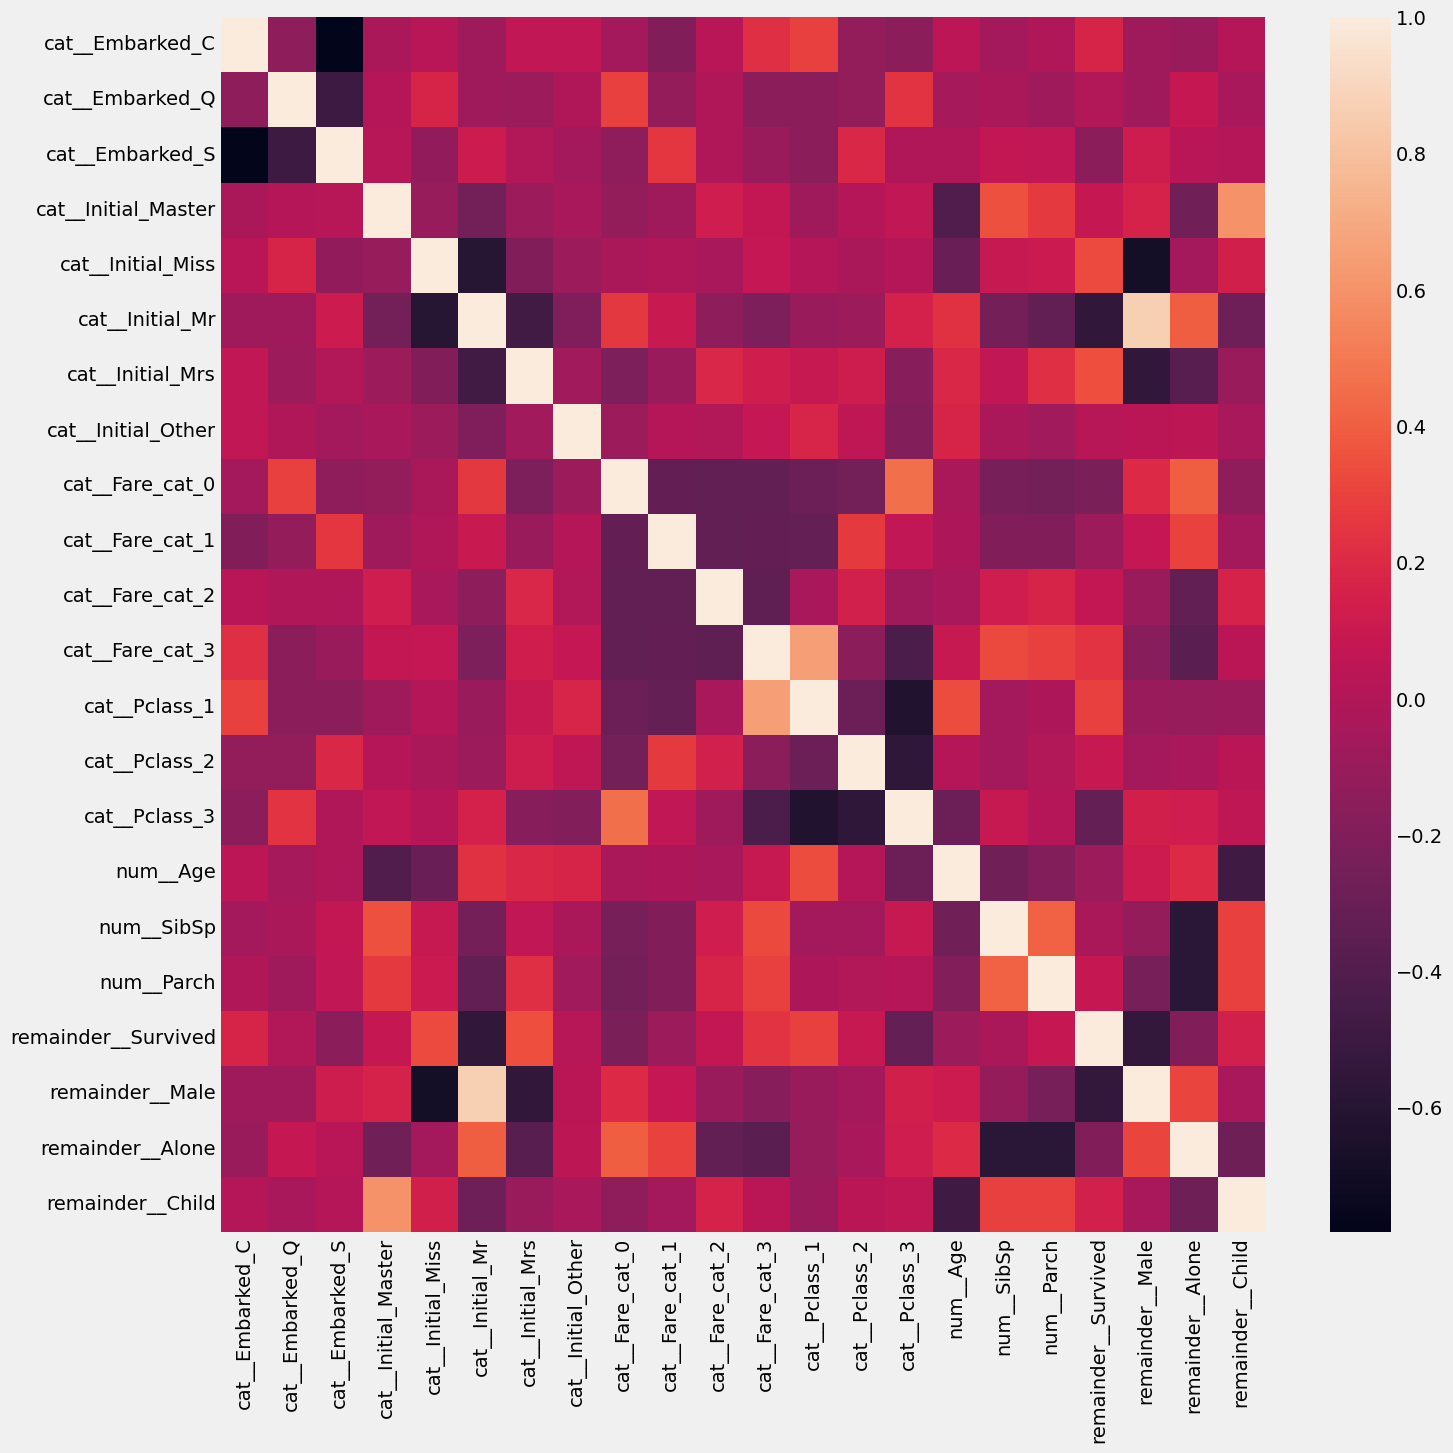

In [21]:
df2 = df.copy(deep=True)

proc = preprocessor(True, True)

np_array = proc.fit_transform(df2)

feature_names = proc.named_steps['cols_transformer'].get_feature_names_out()

df2 = pd.DataFrame(np_array, columns=feature_names, index=df2.index)

fig = plt.figure(figsize=(15,15))
sns.heatmap(df2.corr())
plt.show()


In [22]:
target_corr = df2.corr()['remainder__Survived'].sort_values(ascending=False)
print("Корреляция с выживаемостью:")
print(target_corr)

Корреляция с выживаемостью:
remainder__Survived    1.000000
cat__Initial_Mrs       0.339040
cat__Initial_Miss      0.327093
cat__Pclass_1          0.285904
cat__Fare_cat_3        0.237104
cat__Embarked_C        0.168240
remainder__Child       0.148996
cat__Pclass_2          0.093349
cat__Initial_Master    0.085221
num__Parch             0.081629
cat__Fare_cat_2        0.070293
cat__Initial_Other     0.022030
cat__Embarked_Q        0.003650
num__SibSp            -0.035322
num__Age              -0.086731
cat__Fare_cat_1       -0.087603
cat__Embarked_S       -0.149683
remainder__Alone      -0.203367
cat__Fare_cat_0       -0.221610
cat__Pclass_3         -0.322308
remainder__Male       -0.543351
cat__Initial_Mr       -0.549199
Name: remainder__Survived, dtype: float64


In [23]:
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=[config.target_column_name]), df[config.target_column_name], test_size=0.2, random_state=42, stratify=df[config.target_column_name])



model = CatBoostClassifier(
    iterations=150,
    learning_rate=0.05,
    depth=4,
    l2_leaf_reg=5,
    cat_features=("Pclass", "Embarked", "Fare_cat", "Initial", "Male"),
    bootstrap_type='Bernoulli',     
    subsample=0.7,                  
    rsm=0.7,                        
    random_seed=42,
    verbose=False
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor(is_scale=False, is_cat=False)),
    ('model', model)
])

pipeline.fit(X_train, y_train)

print("Модель успешно обучена!")

preds = pipeline.predict(X_test)
test_acc = accuracy_score(y_test, preds)
print(f"Точность (Accuracy) на тестовой выборке: {test_acc:.4f}")

Модель успешно обучена!
Точность (Accuracy) на тестовой выборке: 0.7989


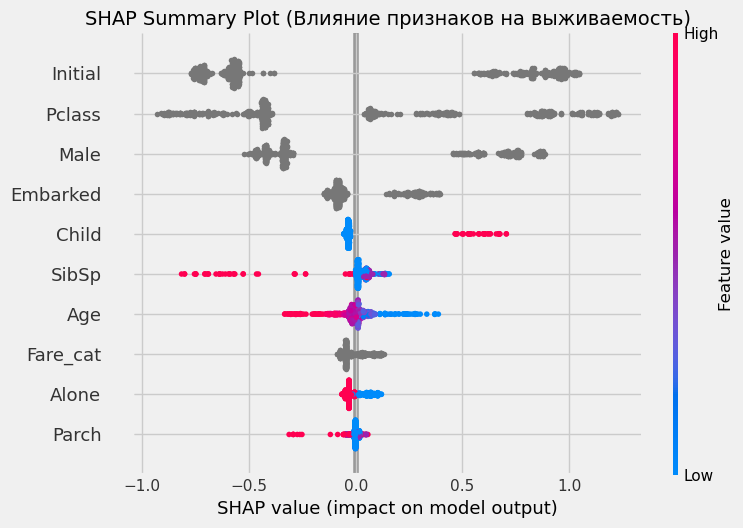

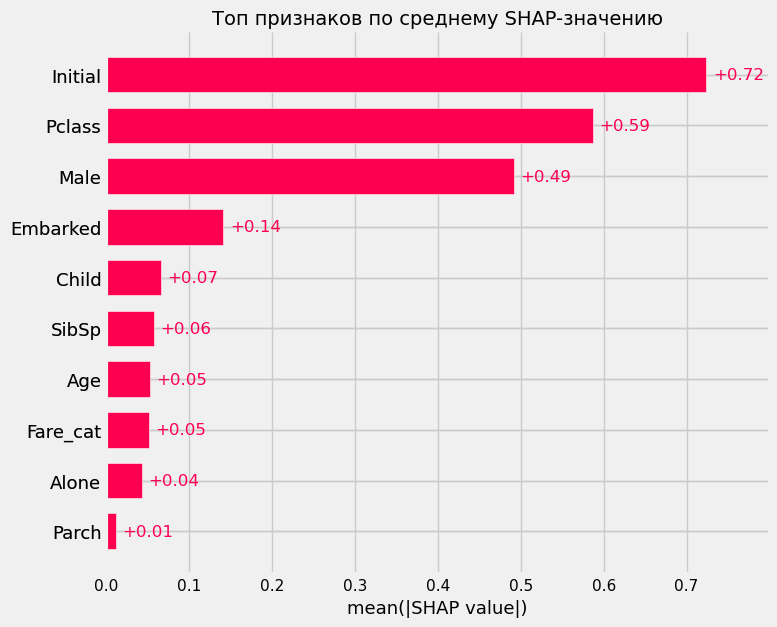

In [ ]:
trained_model = pipeline.named_steps["model"]
preprocessor_step = pipeline.named_steps["preprocessor"]

X_train_transformed = preprocessor_step.transform(X_train)

explainer = shap.TreeExplainer(trained_model)

shap_values = explainer(X_train_transformed)

if isinstance(shap_values, list) or (
    hasattr(shap_values, "shape") and len(shap_values.shape) == 3
):
    shap_values_target = shap_values[:, :, 1]
else:
    shap_values_target = shap_values


plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values_target, X_train_transformed, plot_type="dot", show=False
)
plt.title("SHAP Summary Plot (Влияние признаков на выживаемость)", fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values_target, max_display=15, show=False)
plt.title("Топ признаков по среднему SHAP-значению", fontsize=14)
plt.tight_layout()
plt.show()
